# Many-PT period counts (seed-averaged)

Runs one `(experiment config, optimizer, seed)` simulation at a time using pretrained checkpoints from `results_many_pt_and_sim`, extracts period counts / `t_start` / `length_iter`, deletes bulky `results/` artifacts, and saves compact tables under `save/many_pt_run`.

In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import json
import os
import re
import shutil
import sys
import tempfile
from pathlib import Path
from typing import Any, Iterable, cast

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from tqdm.auto import tqdm


assert False, "Don't run!!! This will delete `results/`"

def _find_project_root(start: Path | None = None) -> Path:
	p = (start or Path.cwd()).resolve()
	for cand in [p, *p.parents]:
		if (cand / "pyproject.toml").is_file():
			return cand
	return p

already_cwd = False
assert not already_cwd
LOCAL_SAVE_DIR = (Path("save") / "many_pt_run").resolve()
PROJECT_ROOT = _find_project_root()
os.chdir(PROJECT_ROOT)
already_cwd = True
if str(PROJECT_ROOT) not in sys.path:
	sys.path.insert(0, str(PROJECT_ROOT))

CONFIG_DIR = PROJECT_ROOT / "results_many_pt_and_sim" / "input_configs_many_pt_and_sim"
PT_ROOT = PROJECT_ROOT / "results_many_pt_and_sim" / "pt_models" / "optimizer_pretrained"
RESULTS_ROOT = PROJECT_ROOT / "results"

OPTIMIZER_NAMES = ["sgd", "adam", "adagrad", "pure_shampoo", "graft_shampoo"]
PT_DIR_BY_OID: dict[str, str] = {
	"grafted_shampoo_lr0.01": "graft_shampoo_lr0.01",
}

MAX_JOBS: int | None = None  # set e.g. 1 for smoke test
DRY_RUN = False

LOCAL_SAVE_DIR.mkdir(parents=True, exist_ok=True)
RUN_SUMMARY_PATH = LOCAL_SAVE_DIR / "run_summary.csv"
PERIODS_LONG_PATH = LOCAL_SAVE_DIR / "periods_long.csv"

from compute_results.config_guard import (
	build_training_config,
	guard_optimizer_config,
	guard_training_config,
	load_existing_optimizer_ids,
	normalize_loss,
	result_id_for_config,
	save_config,
	save_metadata,
	save_optimizer_config,
	validate_experiment_config_constraints,
)
from compute_results.defaults import SHAMPOO_PRECONDITIONER_EPSILON_KEY
from compute_results.run_simulation import (
	_Task,
	_resolve_optimizer,
	_run_single_task,
)
from experiments import get_experiment
from models import get_model, parse_he_init
from optimizers import get_extractor

from visualize_webapp.app import (
	_metrics,
	_nts,
	_opt_color,
	_opt_label,
	_sort_optimizer_ids,
)
from visualize_webapp.notebook.scoring_helpers import (
	filter_periods,
	get_all_points_of_max_acceleration,
	get_iteration,
	get_n_assigned_digits,
	get_recovery_periods,
	is_pretrain_shuffle_mislabel_experiment,
	remove_inelligible_periods,
	index_grp,
)
from visualize_webapp.io import _pp_dead, _pp_neuron_digit

sns.set_theme(context="talk", style="whitegrid", font_scale=0.95)
mpl.rcParams["figure.dpi"] = 120
mpl.rcParams["savefig.dpi"] = 200

_SEED_SUFFIX_RE = re.compile(r"_seed\d+$")

_EXPER_LABEL_SHUFFLE_ALL = r"$\text{Shuffle}_{all}$"
_EXPER_LABEL_SHUFFLE_NOPRE = "Control global (✗PT)"
_EXPER_LABEL_SEQ_NOPRE = "Control sequential (✗PT)"
_EXPER_LABEL_SEQ_PRE = "Control sequential (✔PT)"
_EXPER_LABEL_SHUFFLE_SEQ = "Shuffle (seq)"
_EXPER_LABEL_NO_PRETRAIN = " Control (no pretrain)"


def _experiment_display_sort_rank(lab: str) -> int:
	if lab in (_EXPER_LABEL_SHUFFLE_NOPRE, "Shuffle (no pretrain)", "Control Shuffle (✗PT)"):
		return 100
	if lab != _EXPER_LABEL_SHUFFLE_ALL and lab.startswith(r"$\text{Shuffle}"):
		return 101
	if lab == _EXPER_LABEL_SHUFFLE_ALL:
		return 102
	if lab in (_EXPER_LABEL_SEQ_NOPRE, "Control (✗PT)", "Control (no pretrain)"):
		return 200
	if lab in (_EXPER_LABEL_SEQ_PRE, "Control (✔PT)", "Control (pretrain seq)"):
		return 201
	if lab == _EXPER_LABEL_SHUFFLE_SEQ:
		return 202
	if lab == "Recover":
		return 203
	if lab == "Reinforce":
		return 204
	if lab == "Control":
		return 205
	if lab == _EXPER_LABEL_NO_PRETRAIN:
		return 300
	return 999


def _sort_experiment_display_names(labels: Iterable[str]) -> list[str]:
	uniq = sorted(set(map(str, labels)))
	return sorted(uniq, key=lambda lab: (_experiment_display_sort_rank(lab), lab))


def rename_experiments(exp_name: str) -> str:
	s = str(exp_name)
	if s.startswith("digit_"):
		return _EXPER_LABEL_NO_PRETRAIN
	_c1con = "cat1_sample_shuffle_constrained_digits"
	if s.startswith(_c1con) and "_tr" in s:
		mid = s[len(_c1con) :].split("_tr", 1)[0]
		if mid:
			digits = tuple(int(p) for p in mid.split("-") if p != "")
			inner = ",".join(str(d) for d in digits)
			return r"$\text{Shuffle}_{\{" + inner + r"\}}$"
	if s.startswith("cat1_sample_shuffle_control_tr"):
		return _EXPER_LABEL_SHUFFLE_NOPRE
	if s.startswith("cat1_sample_shuffle_finetune_"):
		return _EXPER_LABEL_SHUFFLE_ALL
	if "pretrain_shuffle_mislabel" in s:
		if "_digits" in s:
			suffix = s.rsplit("_digits", 1)[1]
			digits = tuple(int(part) for part in suffix.split("-") if part != "")
			inner = ",".join(str(d) for d in digits)
			return r"$\text{Shuffle}_{\{" + inner + r"\}}$"
		return _EXPER_LABEL_SHUFFLE_ALL
	if is_pretrain_shuffle_mislabel_experiment(s):
		return _EXPER_LABEL_SHUFFLE_ALL
	if "cat2_sequence_recover" in s:
		return "Recover"
	if "cat2_sequence_reinforce" in s:
		return "Reinforce"
	if "cat2_sequence_labelperm" in s:
		return _EXPER_LABEL_SHUFFLE_SEQ
	if s.startswith("cat2_sequence_pretrain_control_"):
		return _EXPER_LABEL_SEQ_PRE
	if s.startswith("cat2_sequence_control_tr"):
		return _EXPER_LABEL_SEQ_NOPRE
	if "mislabel" in s and "shuffle_mislabel" not in s:
		return "Recover"
	if "relabel" in s:
		return "Reinforce"
	return "Control"


def experiment_slug_from_config_stem(stem: str) -> str:
	return _SEED_SUFFIX_RE.sub("", stem)


print(f"PROJECT_ROOT={PROJECT_ROOT}")
print(f"Configs: {len(list(CONFIG_DIR.glob('*.json')))}")

PROJECT_ROOT=/home/garvalov/thesis/plateau_optimizer/network_analyzer
Configs: 48


In [ ]:


assert False, "Don't run!!! This will delete `results/`"

def parse_config_json(path: Path) -> dict[str, Any]:
	raw = json.loads(path.read_text())
	experiment_kwargs = dict(raw.get("experiment_config", {}))
	if (
		"num_trial_samples" not in experiment_kwargs
		and "num_stage_samples" in experiment_kwargs
	):
		experiment_kwargs["num_trial_samples"] = int(experiment_kwargs["num_stage_samples"])
	model_kwargs = dict(raw.get("model_config", {}) or {})
	if not model_kwargs:
		model_kwargs = {"activation": raw.get("activation", "relu")}
	elif "activation" not in model_kwargs:
		model_kwargs["activation"] = raw.get("activation", "relu")
	opt_extra: dict[str, Any] = {}
	if raw.get(SHAMPOO_PRECONDITIONER_EPSILON_KEY) is not None:
		opt_extra[SHAMPOO_PRECONDITIONER_EPSILON_KEY] = float(raw[SHAMPOO_PRECONDITIONER_EPSILON_KEY])
	return {
		"experiment_class": str(raw["experiment_class"]),
		"experiment_kwargs": experiment_kwargs,
		"model_class": str(raw["model_class"]),
		"model_kwargs": model_kwargs,
		"base_lr": float(raw.get("base_lr", 1e-3)),
		"trial_epochs": int(raw.get("trial_epochs", raw.get("stage_epochs", 1))),
		"batch_size": int(raw.get("batch_size", 1)),
		"seed": int(raw.get("seed", 3003)),
		"activation": str(raw.get("activation", "relu")),
		"checkpoint_cadence": str(raw.get("checkpoint_cadence", "every_epoch")),
		"save_model_cp": bool(raw.get("save_model_cp", False)),
		"he_init": raw.get("he_init", 3),
		"init_epsilon": float(raw.get("init_epsilon", 1e-10)),
		"internal_keep_tensors": bool(raw.get("internal_keep_tensors", False)),
		"experiment_runs": int(raw.get("experiment_runs", raw.get("trials", 3))),
		"experiment_variability": str(raw.get("experiment_variability", raw.get("trial_variability", ""))),
		"loss": str(raw.get("loss", "ce")),
		"config_initial_model_mode": str(raw.get("initial_model_mode", "init") or "init"),
	}


def make_initial_model_bundle(seed_ckpt_dir: Path, registry_class: str) -> Path:
	tmp = Path(tempfile.mkdtemp(prefix="many_pt_init_"))
	sub = tmp / registry_class
	sub.mkdir(parents=True)
	shutil.copy2(seed_ckpt_dir / "model.pt", sub / "model.pt")
	shutil.copy2(seed_ckpt_dir / "optimizer.pt", sub / "optimizer.pt")
	return tmp


def resolve_pretrained_dir(oid: str, seed: int) -> Path:
	pt_name = PT_DIR_BY_OID.get(oid, oid)
	d = PT_ROOT / pt_name / str(seed)
	if not (d / "model.pt").is_file():
		raise FileNotFoundError(f"Missing pretrained model.pt: {d / 'model.pt'}")
	return d


def delete_run_artifacts(results_dir: Path) -> None:
	if results_dir.exists():
		shutil.rmtree(results_dir)


def extract_period_metrics(
	eid: str, mid: str, oid: str, rid: str
) -> tuple[int, pd.DataFrame]:
	"""Minimal period path: counts, length_iter, t_start (no robustness)."""
	empty_cols = [
		"neuron_id",
		"period_id",
		"length_iter",
		"t_start",
	]
	metrics = _metrics(eid, mid, oid, rid=rid, w_cache=False)
	df_nd = cast(pd.DataFrame, _pp_neuron_digit(eid, mid, oid, rid=rid, w_cache=False))
	if df_nd is None or df_nd.empty:
		return 0, pd.DataFrame(columns=empty_cols)

	df_dead = cast(pd.DataFrame | None, _pp_dead(eid, mid, oid, rid=rid, w_cache=False))
	if df_dead is not None and not df_dead.empty:
		df_dead = df_dead.copy()
		df_dead["iteration"] = df_dead["checkpoint_idx"].map(lambda c: get_iteration(metrics, c))
	n_assigned = get_n_assigned_digits(df_nd)
	recovery_periods = get_recovery_periods(
		metrics, df_nd, n_assigned, df_dead, mode="assigned_same"
	)
	recovery_periods = remove_inelligible_periods(
		recovery_periods,
		require_until_trial_end=not is_pretrain_shuffle_mislabel_experiment(eid),
	)
	if df_dead is not None and not df_dead.empty:
		recovery_periods = filter_periods(recovery_periods, df_dead, strict=False)

	n_periods = int(len(recovery_periods))
	if n_periods == 0:
		return 0, pd.DataFrame(columns=empty_cols)

	nts = _nts(eid, mid, oid, rid=rid, w_cache=False)
	peak_agg = "max" if is_pretrain_shuffle_mislabel_experiment(eid) else "min"
	pma = get_all_points_of_max_acceleration(
		nts, recovery_periods, peak_time_aggregate=peak_agg
	).reset_index()
	periods_df = recovery_periods[index_grp + ["total_length_iter"]].merge(
		pma[index_grp + ["point_of_max_acceleration"]],
		on=index_grp,
		how="left",
	)
	periods_df = periods_df.rename(
		columns={
			"total_length_iter": "length_iter",
			"point_of_max_acceleration": "t_start",
		}
	)
	return n_periods, periods_df[empty_cols]


def run_one_job(
	config_path: Path,
	optimizer_name: str,
	*,
	experiment_slug: str,
) -> dict[str, Any]:
	"""Train one optimizer for one config; return metadata + period tables."""
	raw = json.loads(config_path.read_text())
	parsed = parse_config_json(config_path)
	exp_cls = parsed["experiment_class"]
	exp_kw = parsed["experiment_kwargs"]
	mod_cls = parsed["model_class"]
	mod_kw = dict(parsed["model_kwargs"])
	seed = parsed["seed"]
	base_lr = parsed["base_lr"]

	validate_he_init(parsed["he_init"])
	normalize_loss(parsed["loss"])
	validate_experiment_config_constraints(
		exp_cls, exp_kw, experiment_runs=parsed["experiment_runs"]
	)

	opt_extra: dict[str, Any] = {}
	if raw.get(SHAMPOO_PRECONDITIONER_EPSILON_KEY) is not None:
		opt_extra[SHAMPOO_PRECONDITIONER_EPSILON_KEY] = float(raw[SHAMPOO_PRECONDITIONER_EPSILON_KEY])
	opt_class, opt_kwargs = _resolve_optimizer(optimizer_name, base_lr, **opt_extra)

	extractor = get_extractor(opt_class, **opt_kwargs)
	oid = extractor.optimizer_id()

	initial_model_mode = parsed["config_initial_model_mode"]
	use_initial_model = ""
	bundle_tmp: Path | None = None

	if initial_model_mode == "pretrain":
		seed_ckpt = resolve_pretrained_dir(oid, seed)
		bundle_tmp = make_initial_model_bundle(seed_ckpt, opt_class)
		use_initial_model = str(bundle_tmp)

	experiment = get_experiment(exp_cls, **exp_kw)
	model = get_model(mod_cls, **mod_kw)
	config = build_training_config(
		experiment_class=exp_cls,
		experiment_config=exp_kw,
		model_class=mod_cls,
		model_config=mod_kw,
		trial_epochs=parsed["trial_epochs"],
		base_lr=base_lr,
		batch_size=parsed["batch_size"],
		seed=seed,
		activation=mod_kw.get("activation", parsed["activation"]),
		checkpoint_cadence=parsed["checkpoint_cadence"],
		save_model_cp=parsed["save_model_cp"],
		he_init=parsed["he_init"],
		init_epsilon=parsed["init_epsilon"],
		internal_keep_tensors=parsed["internal_keep_tensors"],
		experiment_runs=parsed["experiment_runs"],
		experiment_variability=parsed["experiment_variability"],
		loss=parsed["loss"],
		use_initial_model=use_initial_model,
		initial_model_mode=initial_model_mode,
		optimizer_registry_classes_for_initial_model=[opt_class] if use_initial_model else None,
	)

	eid = experiment.experiment_id()
	mid = model.model_id()
	rid = result_id_for_config(
		config,
		experiment_dir=RESULTS_ROOT / eid,
		model_id=mid,
	)
	results_dir = RESULTS_ROOT / eid / rid / mid

	delete_run_artifacts(results_dir)

	try:
		guard_training_config(results_dir, config)
		save_config(results_dir, config)
		guard_optimizer_config(results_dir / "optimizers" / oid, extractor.optimizer_config(), force=True)
		save_optimizer_config(results_dir / "optimizers" / oid, extractor.optimizer_config())
		existing = load_existing_optimizer_ids(results_dir)
		save_metadata(
			results_dir,
			experiment_class=exp_cls,
			model_class=mod_cls,
			optimizer_ids=sorted(set(existing) | {oid}),
		)

		task = _Task(
			experiment_class=exp_cls,
			experiment_kwargs=exp_kw,
			model_class=mod_cls,
			model_kwargs=mod_kw,
			optimizer_name=optimizer_name,
			optimizer_class=opt_class,
			optimizer_kwargs=opt_kwargs,
			config=config,
			seed=seed,
			results_dir=results_dir,
		)
		_, _, _, ok = _run_single_task(task, device_id=0)
		if not ok:
			raise RuntimeError(f"Training failed: {exp_cls} / {oid} / seed={seed}")

		n_periods, periods_df = extract_period_metrics(eid, mid, oid, rid)
		exp_display = rename_experiments(eid)
		return {
			"config_stem": config_path.stem,
			"experiment": experiment_slug,
			"experiment_display": exp_display,
			"experiment_class": exp_cls,
			"seed": seed,
			"optimizer_id": oid,
			"optimizer_name": optimizer_name,
			"eid": eid,
			"mid": mid,
			"rid": rid,
			"n_periods": n_periods,
			"periods_df": periods_df,
		}
	finally:
		delete_run_artifacts(results_dir)
		if bundle_tmp is not None:
			shutil.rmtree(bundle_tmp, ignore_errors=True)
		if torch.cuda.is_available():
			torch.cuda.empty_cache()

In [4]:
def optimizer_id_for_name(optimizer_name: str, base_lr: float = 0.01) -> str:
	opt_class, opt_kwargs = _resolve_optimizer(optimizer_name, base_lr)
	return get_extractor(opt_class, **opt_kwargs).optimizer_id()


def build_jobs() -> list[dict[str, Any]]:
	jobs: list[dict[str, Any]] = []
	for cfg_path in sorted(CONFIG_DIR.glob("*.json")):
		stem = cfg_path.stem
		slug = experiment_slug_from_config_stem(stem)
		base_lr = float(json.loads(cfg_path.read_text()).get("base_lr", 1e-3))
		for opt_name in OPTIMIZER_NAMES:
			jobs.append(
				{
					"config_path": cfg_path,
					"config_stem": stem,
					"experiment_slug": slug,
					"optimizer_name": opt_name,
					"base_lr": base_lr,
				}
			)
	return jobs


def load_completed_keys() -> set[tuple[str, str]]:
	if not RUN_SUMMARY_PATH.is_file():
		return set()
	df = pd.read_csv(RUN_SUMMARY_PATH)
	return set(zip(df["config_stem"].astype(str), df["optimizer_id"].astype(str)))


def append_and_save(run_row: dict[str, Any], periods_df: pd.DataFrame) -> None:
	global run_summary, periods_long
	run_summary = pd.concat([run_summary, pd.DataFrame([run_row])], ignore_index=True)
	if not periods_df.empty:
		pl = periods_df.copy()
		for col in (
			"config_stem",
			"experiment",
			"experiment_display",
			"seed",
			"optimizer_id",
			"eid",
			"mid",
			"rid",
		):
			pl[col] = run_row[col]
		periods_long = pd.concat([periods_long, pl], ignore_index=True)
	run_summary.to_csv(RUN_SUMMARY_PATH, index=False)
	periods_long.to_csv(PERIODS_LONG_PATH, index=False)


if RUN_SUMMARY_PATH.is_file():
	run_summary = pd.read_csv(RUN_SUMMARY_PATH)
else:
	run_summary = pd.DataFrame(
		columns=[
			"config_stem",
			"experiment",
			"experiment_display",
			"experiment_class",
			"seed",
			"optimizer_id",
			"optimizer_name",
			"eid",
			"mid",
			"rid",
			"n_periods",
		]
	)

if PERIODS_LONG_PATH.is_file():
	periods_long = pd.read_csv(PERIODS_LONG_PATH)
else:
	periods_long = pd.DataFrame(
		columns=[
			"config_stem",
			"experiment",
			"experiment_display",
			"seed",
			"optimizer_id",
			"eid",
			"mid",
			"rid",
			"neuron_id",
			"period_id",
			"length_iter",
			"t_start",
		]
	)

jobs = build_jobs()
completed = load_completed_keys()
pending = [
	j
	for j in jobs
	if (j["config_stem"], optimizer_id_for_name(j["optimizer_name"], j["base_lr"])) not in completed
]
if MAX_JOBS is not None:
	pending = pending[: int(MAX_JOBS)]
print(f"Total jobs: {len(jobs)}, completed: {len(completed)}, pending: {len(pending)}")
print(f"Resume file: {RUN_SUMMARY_PATH}")

Total jobs: 240, completed: 240, pending: 0
Resume file: /home/garvalov/thesis/plateau_optimizer/network_analyzer/local/save/many_pt_run/run_summary.csv


In [5]:
failures: list[dict[str, Any]] = []

assert False, "Don't run!!! This will delete `results/`"

for job in tqdm(pending, desc="many_pt runs"):
	desc = f"{job['experiment_slug']} / {job['optimizer_name']} / {job['config_stem']}"
	if DRY_RUN:
		tqdm.write(f"[dry-run] {desc}")
		continue
	try:
		out = run_one_job(
			job["config_path"],
			job["optimizer_name"],
			experiment_slug=job["experiment_slug"],
		)
		run_row = {k: v for k, v in out.items() if k != "periods_df"}
		append_and_save(run_row, out["periods_df"])
	except Exception as exc:
		tqdm.write(f"FAILED {desc}: {exc}")
		failures.append({**job, "error": str(exc)})

if failures:
	pd.DataFrame(failures).to_csv(LOCAL_SAVE_DIR / "failures.csv", index=False)
	print(f"Failures: {len(failures)} (see failures.csv)")
else:
	print("All pending jobs completed without recorded failures.")

print(f"run_summary rows: {len(run_summary)}")
print(f"periods_long rows: {len(periods_long)}")

many_pt runs: 0it [00:00, ?it/s]

All pending jobs completed without recorded failures.
run_summary rows: 240
periods_long rows: 14402


Mean n_periods per experiment (over seeds and optimizers):
  Control global (✗PT): 105.133 (n=30)
  $\text{Shuffle}_{\{0,1\}}$: 3.600 (n=30)
  $\text{Shuffle}_{all}$: 22.600 (n=30)
  Control sequential (✗PT): 93.300 (n=30)
  Control sequential (✔PT): 16.133 (n=30)
  Shuffle (seq): 35.367 (n=30)
  Recover: 94.433 (n=30)
  Reinforce: 109.500 (n=30)


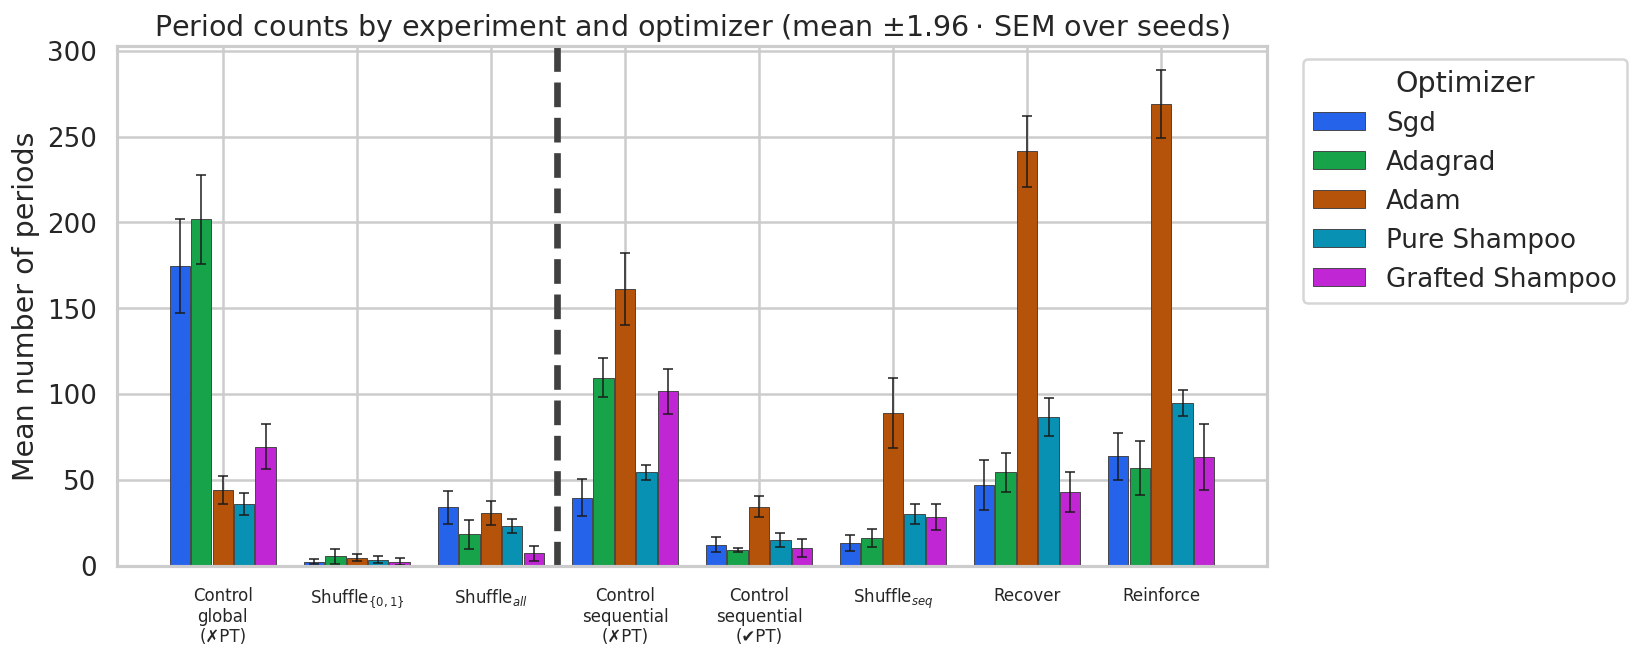

Saved /home/garvalov/thesis/plateau_optimizer/network_analyzer/local/save/many_pt_run/period_counts_mean_sem.pdf


/tmp/ipykernel_27991/3587268100.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_27991/3587268100.py:90: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([" ".join([optimizer_part.lower().capitalize() for optimizer_part in _opt_label(o).split("_")]) for o in order], rotation=20, ha="right")
/tmp/ipykernel_27991/3587268100.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_27991/3587268100.py:90: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([" ".join([o

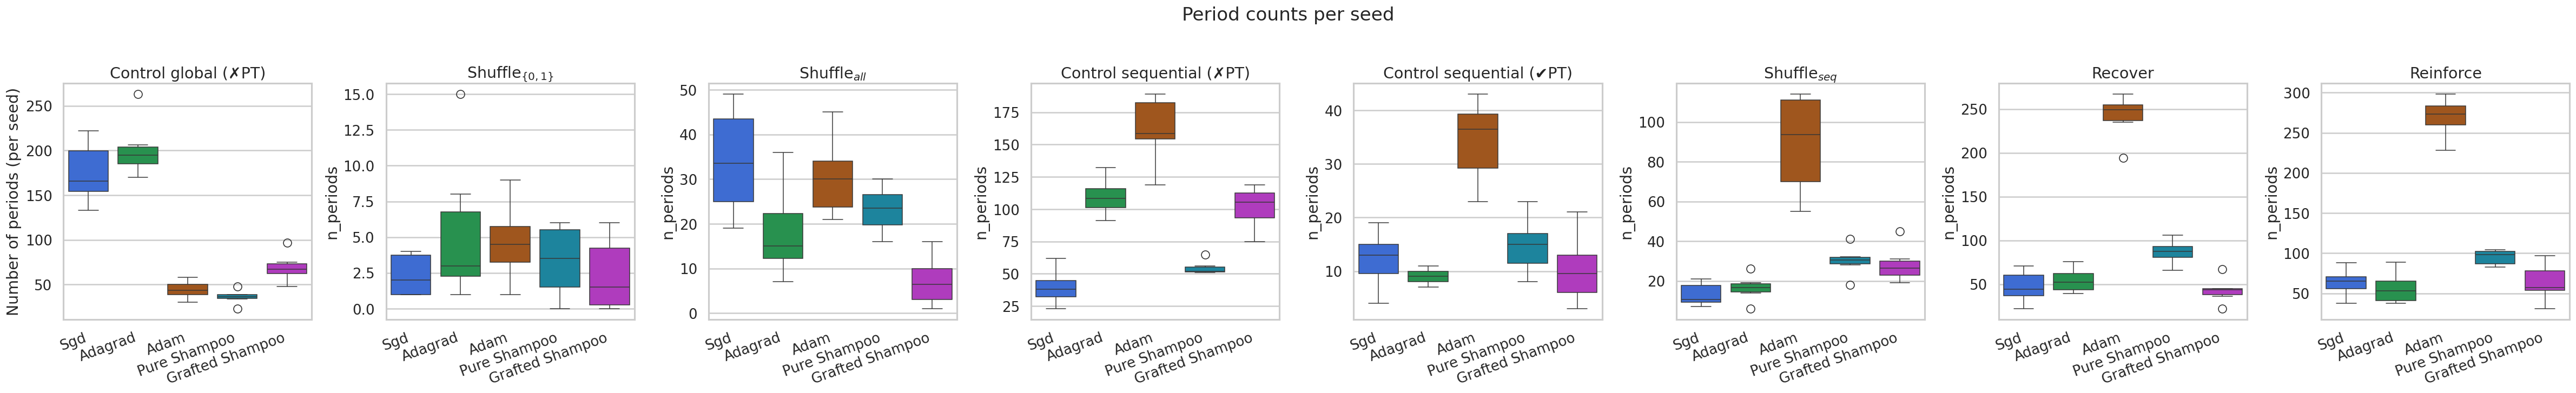

Saved /home/garvalov/thesis/plateau_optimizer/network_analyzer/local/save/many_pt_run/period_counts_per_seed_box.pdf


In [6]:
if run_summary.empty:
	print("No run_summary data to plot yet.")
else:
	dfp = run_summary.copy()
	dfp["experiment_plot"] = dfp["experiment_display"].fillna(dfp["experiment"])

	agg = (
		dfp.groupby(["experiment_plot", "optimizer_id"], as_index=False)
		.agg(
			mean_n=("n_periods", "mean"),
			sem_n=(
				"n_periods",
				lambda s: float(s.std(ddof=1) / np.sqrt(len(s))) if len(s) > 1 else 0.0,
			),
			n_seeds=("n_periods", "count"),
		)
	)
	agg["yerr"] = 1.96 * agg["sem_n"]

	exp_order = _sort_experiment_display_names(agg["experiment_plot"].unique())
	opt_order = _sort_optimizer_ids(agg["optimizer_id"].unique().tolist())
	palette = [_opt_color(o) for o in opt_order]

	exp_means = (
		dfp.groupby("experiment_plot")["n_periods"]
		.agg(mean_n="mean", n_runs="count")
		.reindex(exp_order)
	)
	print("Mean n_periods per experiment (over seeds and optimizers):")
	for exp, row in exp_means.iterrows():
		print(f"  {exp}: {row['mean_n']:.3f} (n={int(row['n_runs'])})")

	fig, ax = plt.subplots(figsize=(max(10, len(exp_order) * 1.75), 5.8))
	x = np.arange(len(exp_order))
	width = 0.8 / max(len(opt_order), 1)

	for i, oid in enumerate(opt_order):
		sub = agg[agg["optimizer_id"] == oid].set_index("experiment_plot").reindex(exp_order)
		offset = (i - (len(opt_order) - 1) / 2.0) * width
		if i == len(opt_order) - 1:
			ax.axvline(x=2+offset+0.17, color="0.25", linestyle="--", linewidth=4)
		ax.bar(
			x + offset,
			sub["mean_n"].to_numpy(),
			width=width * 0.95,
			yerr=sub["yerr"].to_numpy(),
			label=" ".join([optimizer_part.lower().capitalize() for optimizer_part in _opt_label(oid).split("_")]),
			color=_opt_color(oid),
			edgecolor="0.25",
			linewidth=0.55,
			capsize=3,
			error_kw={"elinewidth": 0.9, "capthick": 0.9},
		)

	ax.set_xticks(x)
	ax.set_xticklabels(["\n".join(e.replace(_EXPER_LABEL_SHUFFLE_SEQ,r"$\text{Shuffle}_{seq}$").split(" ")) for e in exp_order],fontsize=10)
	ax.set_xlabel("")
	ax.set_ylabel("Mean number of periods")
	ax.set_title("Period counts by experiment and optimizer (mean "+r"$\pm 1.96\cdot\,\text{SEM}$"+" over seeds)")
	ax.legend(title="Optimizer", bbox_to_anchor=(1.02, 1), loc="upper left")
	plt.tight_layout()
	out_pdf = LOCAL_SAVE_DIR / "period_counts_mean_sem.pdf"
	plt.savefig(out_pdf, bbox_inches="tight")
	plt.show()
	print(f"Saved {out_pdf}")

	# Optional: per-experiment boxplots of per-seed n_periods
	fig2, axes = plt.subplots(
		1,
		len(exp_order),
		figsize=(max(8, 5 * len(exp_order)), 6),
		squeeze=False,
	)
	for i,(ax, exp) in enumerate(zip(axes.ravel(), exp_order)):
		sub = dfp[dfp["experiment_plot"] == exp]
		order = _sort_optimizer_ids(sub["optimizer_id"].unique().tolist())
		if len(order) < 2:
			ax.set_visible(False)
			continue
		sns.boxplot(
			data=sub,
			x="optimizer_id",
			y="n_periods",
			order=order,
			palette=[_opt_color(o) for o in order],
			ax=ax,
			linewidth=0.9,
			showfliers=True,
		)
		ax.set_xticklabels([" ".join([optimizer_part.lower().capitalize() for optimizer_part in _opt_label(o).split("_")]) for o in order], rotation=20, ha="right")
		ax.set_title(str(exp.replace("Shuffle (seq)",r"$\text{Shuffle}_{seq}$")))
		ax.set_xlabel("")
		if i == 0:
			ax.set_ylabel("Number of periods (per seed)")
	fig2.suptitle("Period counts per seed", y=1.02)
	plt.tight_layout()
	out_box = LOCAL_SAVE_DIR / "period_counts_per_seed_box.pdf"
	plt.savefig(out_box, bbox_inches="tight")
	plt.show()
	print(f"Saved {out_box}")